In [ ]:

# 0. INSTALLS + IMPORTS
!pip -q install pandas requests flask matplotlib

import os, sys, json, time, sqlite3, subprocess, zipfile
from pathlib import Path

import pandas as pd
import requests
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

print("Environment ready.")

Environment ready.


In [ ]:
# 1. LOAD THE CLASSROOM PACK
# In Colab, upload FlashEats_Classroom_Pack.zip when prompted.

BASE = Path("/content/flasheats-classroom-pack.zip")

if not BASE.exists():
    try:
        from google.colab import files
        print("Upload FlashEats_Classroom_Pack.zip")
        uploaded = files.upload()
        zip_name = next(name for name in uploaded if name.endswith(".zip"))
        with zipfile.ZipFile(zip_name, "r") as z:
            z.extractall("/content")
    except Exception as e:
        print("If running locally, set BASE manually to the extracted pack.")
        print(e)

print("BASE:", BASE)
print("Exists:", BASE.exists())


BASE: /content/flasheats-classroom-pack.zip
Exists: True


In [ ]:
from pathlib import Path

matches = list(Path("/content").rglob("flasheats.db"))

print("Found:", len(matches))

for path in matches:
    print(path)

Found: 0


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    level = root.replace("/content", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}  {file}")


content/
  flasheats-classroom-pack.zip
  .config/
    .last_survey_prompt.yaml
    .last_opt_in_prompt.yaml
    .last_update_check.json
    gce
    hidden_gcloud_config_universe_descriptor_data_cache_configs.db
    default_configs.db
    config_sentinel
    active_config
    configurations/
      config_default
    logs/
      2026.09.04/
        13.24.31.709670.log
        13.24.51.717993.log
        13.24.04.448016.log
        13.24.48.959800.log
        13.25.10.757956.log
        13.25.09.479018.log
  sample_data/
    README.md
    anscombe.json
    mnist_test.csv
    california_housing_test.csv
    california_housing_train.csv
    mnist_train_small.csv


In [ ]:
from pathlib import Path
import zipfile

zip_path = Path("/content/flasheats-classroom-pack.zip")
extract_dir = Path("/content")

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

print("Extraction complete.")

Extraction complete.


In [ ]:
from pathlib import Path

db_matches = list(Path("/content").rglob("flasheats.db"))

print("Databases found:", len(db_matches))

for path in db_matches:
    print(path)

Databases found: 1
/content/flasheats-classroom-pack/database/flasheats.db


In [ ]:
# 3. BASIC SYNTAX — READ EVERY SOURCE

# SQLite
db_path = db_matches[0]
BASE = db_path.parent.parent

print("BASE:", BASE)
print("Database:", db_path)
print("Database exists:", db_path.exists())
con = sqlite3.connect(db_path)

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    con
)
display(tables)

sample_orders = pd.read_sql("SELECT * FROM orders LIMIT 5;", con)
display(sample_orders)

# CSV
tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")
display(tickets.head())

# Nested JSON
with open(BASE / "data" / "driver_events.json", "r") as f:
    driver_events = json.load(f)

print("Driver objects:", len(driver_events))
display(driver_events[:1])

BASE: /content/flasheats-classroom-pack
Database: /content/flasheats-classroom-pack/database/flasheats.db
Database exists: True


,name
0,customers
1,drivers
2,orders
3,restaurants


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,None,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


,ticket_id,order_id,created_at,category,customer_message
0,T00001,O00006,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,O00018,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,O00034,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,driver_not_moving,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Driver objects: 120


[{'driver_id': 'D001',
  'events': [{'order_id': 'O00162',
    'type': 'assigned',
    'timestamp': '2026-08-26T17:53:25.977803'},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:10:59.372420',
    'lat': 12.826339,
    'lon': 77.448282},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:28:32.767037',
    'lat': 12.876013,
    'lon': 77.477707},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:46:06.161653',
    'lat': 12.925686,
    'lon': 77.507133},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T19:03:39.556270',
    'lat': 12.97536,
    'lon': 77.536558},
   {'order_id': 'O00162',
    'type': 'picked_up',
    'timestamp': '2026-08-26T18:27:32.131791'},
   {'order_id': 'O00162',
    'type': 'delivered',
    'timestamp': '2026-08-26T19:21:12.950887'},
   {'order_id': 'O00180',
    'type': 'assigned',
    'timestamp': '2026-08-08T18:05:08.439625'},
   {'o

Challenge 1 — How large is the late-delivery problem?
Before coding, decide:

Late means: ______________________________
Denominator: _____________________________
Cancelled orders: include / exclude / other?
Missing actual delivery timestamp: what will you do?
Row grain: what does one row represent?
Required analysis
valid delivered orders,
late count and percentage,
median lateness among late orders,
worst delayed orders,
any data-quality issue that changes the metric.

In [ ]:
orders = pd.read_sql(
    "SELECT * FROM orders;",
    con
)

print("Rows:", len(orders))
print("Columns:")
print(orders.columns.tolist())

display(orders.head())

Rows: 1603
Columns:
['order_id', 'customer_id', 'restaurant_id', 'driver_id', 'city', 'created_at', 'promised_eta', 'pickup_at', 'actual_delivery_at', 'final_status', 'distance_km_estimate', 'traffic_bucket', 'weather_bucket']


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,None,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


In [ ]:
print(orders.dtypes)

order_id                 object
customer_id              object
restaurant_id            object
driver_id                object
city                     object
created_at               object
promised_eta             object
pickup_at                object
actual_delivery_at       object
final_status             object
distance_km_estimate    float64
traffic_bucket           object
weather_bucket           object
dtype: object


In [ ]:
print("Duplicate order IDs:")

print(
    orders["order_id"].duplicated().sum()
)

Duplicate order IDs:
3


In [ ]:
orders["final_status"].value_counts(dropna=False)

,count
final_status,
delivered,1535
cancelled,68


In [ ]:
orders["promised_eta"] = pd.to_datetime(
    orders["promised_eta"],
    errors="coerce"
)

orders["actual_delivery_at"] = pd.to_datetime(
    orders["actual_delivery_at"],
    errors="coerce"
)

In [ ]:
print("Missing promised ETA:",
      orders["promised_eta"].isna().sum())

print("Missing actual delivery:",
      orders["actual_delivery_at"].isna().sum())

Missing promised ETA: 792
Missing actual delivery: 105


In [ ]:
orders["delay_min"] = (
    orders["actual_delivery_at"] -
    orders["promised_eta"]
).dt.total_seconds() / 60

In [ ]:
display(
    orders[
        [
            "order_id",
            "promised_eta",
            "actual_delivery_at",
            "final_status",
            "delay_min"
        ]
    ].head(20)
)

,order_id,promised_eta,actual_delivery_at,final_status,delay_min
0,O00001,2026-08-13 14:11:36,2026-08-13 14:22:25.035899,delivered,10.817265
1,O00002,NaT,2026-08-01 19:47:14.818533,delivered,NaN
2,O00003,NaT,2026-08-01 20:13:28.061191,delivered,NaN
3,O00004,NaT,NaT,cancelled,NaN
4,O00005,2026-08-06 21:54:48,2026-08-06 22:15:49.290713,delivered,21.021512
5,O00006,NaT,2026-08-27 00:05:36.182189,delivered,NaN
6,O00007,2026-08-14 13:14:54,2026-08-14 13:19:10.066680,delivered,4.267778
7,O00008,2026-08-27 23:40:06,2026-08-28 00:06:57.494136,delivered,26.858236
8,O00009,NaT,2026-08-09 14:22:13.491008,delivered,NaN
9,O00010,NaT,2026-08-22 14:22:26.150344,delivered,NaN


In [ ]:
valid_delivered = orders[
    (orders["final_status"] == "delivered") &
    (orders["promised_eta"].notna()) &
    (orders["actual_delivery_at"].notna())
].copy()

print("Valid delivered orders:", len(valid_delivered))

Valid delivered orders: 754


In [ ]:
display(
    valid_delivered[
        [
            "order_id",
            "promised_eta",
            "actual_delivery_at",
            "delay_min",
            "final_status"
        ]
    ].head(10)
)

,order_id,promised_eta,actual_delivery_at,delay_min,final_status
0,O00001,2026-08-13 14:11:36,2026-08-13 14:22:25.035899,10.817265,delivered
4,O00005,2026-08-06 21:54:48,2026-08-06 22:15:49.290713,21.021512,delivered
6,O00007,2026-08-14 13:14:54,2026-08-14 13:19:10.066680,4.267778,delivered
7,O00008,2026-08-27 23:40:06,2026-08-28 00:06:57.494136,26.858236,delivered
13,O00014,2026-08-22 19:56:36,2026-08-22 20:01:42.256596,5.104277,delivered
14,O00015,2026-08-16 20:32:36,2026-08-16 20:36:53.095103,4.284918,delivered
15,O00016,2026-08-14 14:11:06,2026-08-14 14:13:35.547689,2.492461,delivered
17,O00018,2026-08-24 15:00:24,2026-08-24 15:09:50.026151,9.433769,delivered
20,O00021,2026-08-10 13:26:24,2026-08-10 13:18:22.060190,-8.032330,delivered
24,O00025,2026-08-01 13:29:36,2026-08-01 13:20:06.003033,-9.499949,delivered


In [ ]:
late_orders = valid_delivered[
    valid_delivered["delay_min"] > 0
].copy()

late_count = len(late_orders)
total_valid = len(valid_delivered)

late_percentage = late_count / total_valid * 100

print("Valid delivered orders:", total_valid)
print("Late orders:", late_count)
print("Late percentage:", round(late_percentage, 2), "%")

Valid delivered orders: 754
Late orders: 428
Late percentage: 56.76 %


In [ ]:
duplicates = orders[
    orders["order_id"].duplicated(keep=False)
].sort_values("order_id")

display(duplicates)

,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket,delay_min
119,O00120,C0501,R040,D045,Bengaluru,2026-08-13T18:15:00,2026-08-13 19:40:24,2026-08-13T18:29:08.055622,2026-08-13 19:34:08.431508,delivered,18.00,severe,clear,-6.259475
1600,O00120,C0501,R040,D045,Bengaluru,2026-08-13T18:15:00,2026-08-13 19:40:24,2026-08-13T18:29:08.055622,2026-08-13 19:34:08.431508,delivered,18.00,medium,clear,-6.259475
722,O00723,C0467,R028,D068,Bengaluru,2026-08-05T21:04:00,2026-08-05 22:19:36,2026-08-05T21:15:24.433874,2026-08-05 22:04:30.928322,delivered,18.00,medium,clear,-15.084528
1601,O00723,C0467,R028,D068,Bengaluru,2026-08-05T21:04:00,2026-08-05 22:19:36,2026-08-05T21:15:24.433874,2026-08-05 22:04:30.928322,delivered,18.00,high,clear,-15.084528
1301,O01302,C0116,R010,D088,Bengaluru,2026-08-26T21:07:00,NaT,2026-08-26T21:35:26.474087,2026-08-26 22:20:27.428561,delivered,14.78,medium,clear,NaN
1602,O01302,C0116,R010,D088,Bengaluru,2026-08-26T21:07:00,NaT,2026-08-26T21:35:26.474087,2026-08-26 22:20:27.428561,delivered,14.78,high,clear,NaN


In [ ]:
print("Late orders:", late_count)
print("Late percentage:", round(late_percentage, 2), "%")

Late orders: 428
Late percentage: 56.76 %


In [ ]:
# Median lateness among late orders
print(
    "Median lateness:",
    round(late_orders["delay_min"].median(), 2),
    "minutes"
)

Median lateness: 8.2 minutes


In [ ]:
# Worst delayed orders
worst_delayed = (
    late_orders
    .sort_values("delay_min", ascending=False)
    .head(10)
)

display(
    worst_delayed[
        [
            "order_id",
            "customer_id",
            "restaurant_id",
            "driver_id",
            "promised_eta",
            "actual_delivery_at",
            "delay_min",
            "city",
            "traffic_bucket",
            "weather_bucket"
        ]
    ]
)

,order_id,customer_id,restaurant_id,driver_id,promised_eta,actual_delivery_at,delay_min,city,traffic_bucket,weather_bucket
472,O00473,C0719,R002,D064,2026-08-14 20:17:48,2026-08-14 21:04:00.769224,46.212820,Bengaluru,high,clear
193,O00194,C0771,R020,D018,2026-08-11 19:01:48,2026-08-11 19:40:08.111510,38.335192,Bengaluru,high,heavy_rain
1311,O01312,C0206,R027,D056,2026-08-14 20:17:36,2026-08-14 20:54:36.321890,37.005365,Bengaluru,medium,clear
1402,O01403,C0497,R014,D099,2026-08-24 18:47:36,2026-08-24 19:24:32.047659,36.934128,Bengaluru,medium,heavy_rain
459,O00460,C0087,R026,D104,2026-08-12 17:52:24,2026-08-12 18:29:16.970368,36.882839,Bengaluru,severe,clear
496,O00497,C0482,R032,D075,2026-08-13 20:44:18,2026-08-13 21:16:04.765594,31.779427,Bengaluru,high,rain
994,O00995,C0746,R020,D040,2026-08-22 18:45:48,2026-08-22 19:17:31.238213,31.720637,Bengaluru,low,clear
1196,O01197,C0032,R034,D118,2026-08-17 17:56:18,2026-08-17 18:27:54.591417,31.609857,Bengaluru,high,rain
1512,O01513,C0268,R003,D113,2026-08-08 20:09:48,2026-08-08 20:41:15.654928,31.460915,Bengaluru,high,clear
1143,O01144,C0788,R055,D017,2026-08-26 23:21:18,2026-08-26 23:51:26.036977,30.133950,Bengaluru,high,rain


In [ ]:
traffic_analysis = (
    valid_delivered
    .groupby("traffic_bucket")
    .agg(
        orders=("order_id", "count"),
        late_orders=("delay_min", lambda x: (x > 0).sum()),
        late_rate=("delay_min", lambda x: (x > 0).mean() * 100),
        median_delay=("delay_min", "median")
    )
    .reset_index()
)

traffic_analysis["late_rate"] = traffic_analysis["late_rate"].round(2)
traffic_analysis["median_delay"] = traffic_analysis["median_delay"].round(2)

display(traffic_analysis)

,traffic_bucket,orders,late_orders,late_rate,median_delay
0,high,208,138,66.35,3.45
1,low,192,93,48.44,-0.18
2,medium,287,154,53.66,1.20
3,severe,67,43,64.18,4.43


In [ ]:
weather_analysis = (
    valid_delivered
    .groupby("weather_bucket")
    .agg(
        orders=("order_id", "count"),
        late_orders=("delay_min", lambda x: (x > 0).sum()),
        late_rate=("delay_min", lambda x: (x > 0).mean() * 100),
        median_delay=("delay_min", "median")
    )
    .reset_index()
)

weather_analysis["late_rate"] = weather_analysis["late_rate"].round(2)
weather_analysis["median_delay"] = weather_analysis["median_delay"].round(2)

display(weather_analysis)

,weather_bucket,orders,late_orders,late_rate,median_delay
0,clear,592,311,52.53,0.71
1,heavy_rain,42,30,71.43,7.14
2,rain,120,87,72.50,5.84


In [ ]:
valid_delivered["distance_bucket"] = pd.cut(
    valid_delivered["distance_km_estimate"],
    bins=[0, 5, 10, 15, 20, float("inf")],
    labels=["0–5 km", "5–10 km", "10–15 km", "15–20 km", "20+ km"],
    include_lowest=True
)

distance_analysis = (
    valid_delivered
    .groupby("distance_bucket", observed=True)
    .agg(
        orders=("order_id", "count"),
        late_orders=("delay_min", lambda x: (x > 0).sum()),
        late_rate=("delay_min", lambda x: (x > 0).mean() * 100),
        median_delay=("delay_min", "median")
    )
    .reset_index()
)

distance_analysis["late_rate"] = distance_analysis["late_rate"].round(2)
distance_analysis["median_delay"] = distance_analysis["median_delay"].round(2)

display(distance_analysis)

,distance_bucket,orders,late_orders,late_rate,median_delay
0,0–5 km,1,1,100.00,5.78
1,15–20 km,753,427,56.71,1.39


In [ ]:
orders["created_at"] = pd.to_datetime(
    orders["created_at"],
    errors="coerce"
)

valid_delivered["created_at"] = pd.to_datetime(
    valid_delivered["created_at"],
    errors="coerce"
)

In [ ]:
valid_delivered["hour"] = valid_delivered["created_at"].dt.hour

valid_delivered["time_bucket"] = pd.cut(
    valid_delivered["hour"],
    bins=[0, 11, 15, 18, 21, 24],
    labels=[
        "Morning",
        "Lunch",
        "Afternoon",
        "Dinner",
        "Late night"
    ],
    right=False
)

time_analysis = (
    valid_delivered
    .groupby("time_bucket", observed=True)
    .agg(
        orders=("order_id", "count"),
        late_orders=("delay_min", lambda x: (x > 0).sum()),
        late_rate=("delay_min", lambda x: (x > 0).mean() * 100),
        median_delay=("delay_min", "median")
    )
    .reset_index()
)

time_analysis["late_rate"] = time_analysis["late_rate"].round(2)
time_analysis["median_delay"] = time_analysis["median_delay"].round(2)

display(time_analysis)

,time_bucket,orders,late_orders,late_rate,median_delay
0,Lunch,204,111,54.41,1.11
1,Afternoon,128,81,63.28,3.52
2,Dinner,305,176,57.70,1.65
3,Late night,117,60,51.28,0.41


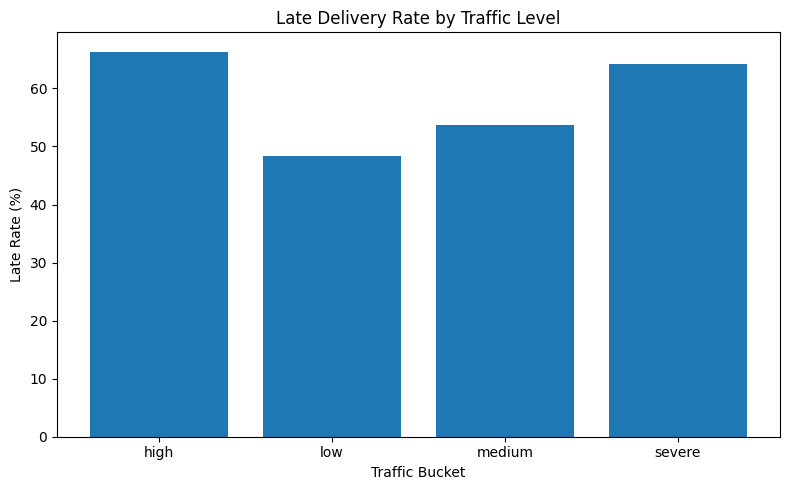

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    traffic_analysis["traffic_bucket"],
    traffic_analysis["late_rate"]
)

plt.xlabel("Traffic Bucket")
plt.ylabel("Late Rate (%)")
plt.title("Late Delivery Rate by Traffic Level")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

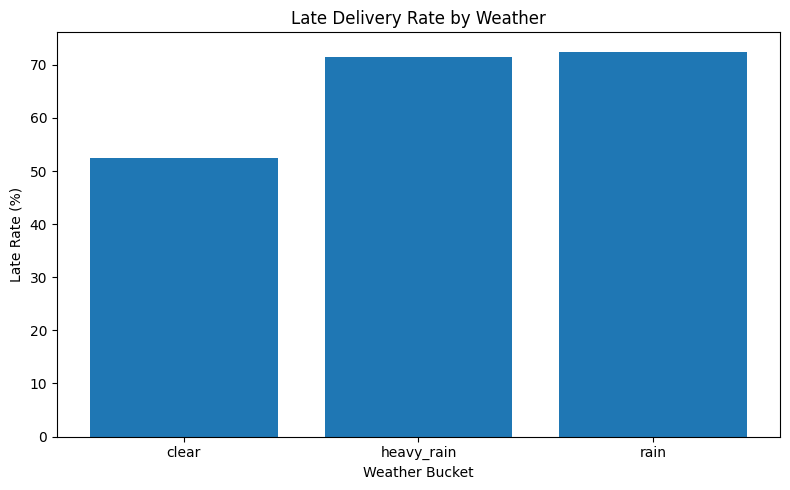

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    weather_analysis["weather_bucket"],
    weather_analysis["late_rate"]
)

plt.xlabel("Weather Bucket")
plt.ylabel("Late Rate (%)")
plt.title("Late Delivery Rate by Weather")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

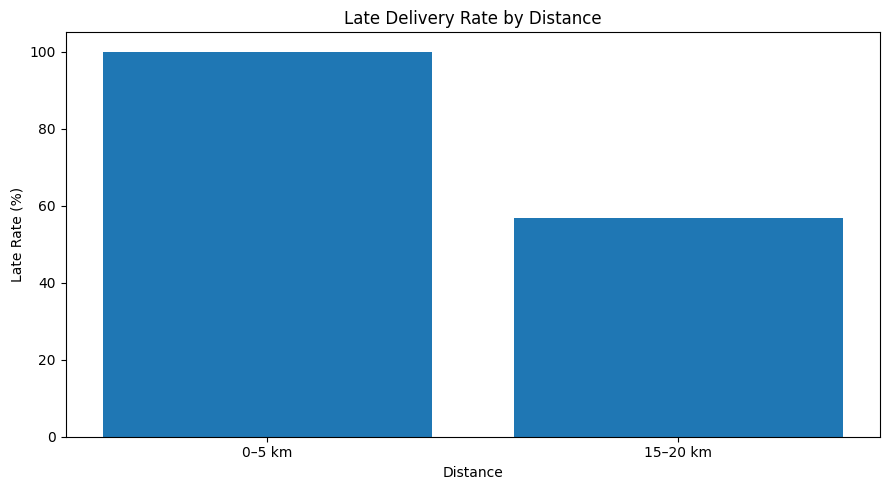

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    distance_analysis["distance_bucket"],
    distance_analysis["late_rate"]
)

plt.xlabel("Distance")
plt.ylabel("Late Rate (%)")
plt.title("Late Delivery Rate by Distance")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Dispatch API endpoint
API_URL = "http://127.0.0.1:8000/dispatch/orders"

print(API_URL)

http://127.0.0.1:8000/dispatch/orders


In [ ]:
# ============================================================
# Challenge 4 — Reliable Dispatch API ingestion
# ============================================================

RAW_DIR = BASE / "student_output" / "raw_dispatch"
RAW_DIR.mkdir(parents=True, exist_ok=True)

import json
import time
import requests


def fetch_all_dispatch_orders(
    api_url=API_URL,
    page_size=50,
    max_retries=5,
    retry_wait=1
):
    """
    Reliably retrieve every Dispatch API record.

    Requirements:
    - Fetch every page
    - Retry HTTP 500 / 429
    - Preserve every successful raw response
    - Fail clearly on unrecoverable errors
    - Verify final record count against API-reported total
    """

    records = []
    page = 1
    successful_pages = 0

    while True:

        print(f"Fetching page {page}...")

        for attempt in range(1, max_retries + 1):

            try:
                response = requests.get(
                    api_url,
                    params={
                        "page": page,
                        "page_size": page_size
                    },
                    timeout=10
                )

            except requests.RequestException as e:

                if attempt == max_retries:
                    raise RuntimeError(
                        f"Page {page} failed after {max_retries} attempts: {e}"
                    )

                print(
                    f"  Request error on attempt {attempt}. "
                    f"Retrying in {retry_wait}s..."
                )

                time.sleep(retry_wait)
                continue

            # Retryable HTTP failures
            if response.status_code in [429, 500]:

                if attempt == max_retries:
                    raise RuntimeError(
                        f"Page {page} returned HTTP "
                        f"{response.status_code} after "
                        f"{max_retries} attempts."
                    )

                print(
                    f"  HTTP {response.status_code} "
                    f"on attempt {attempt}. "
                    f"Retrying in {retry_wait}s..."
                )

                time.sleep(retry_wait)
                continue

            # Any other non-success response
            response.raise_for_status()

            # Successful response
            payload = response.json()
            break

        # ----------------------------------------------------
        # Validate response structure
        # ----------------------------------------------------

        required_keys = {
            "data",
            "has_more",
            "total_records"
        }

        missing_keys = required_keys - payload.keys()

        if missing_keys:
            raise RuntimeError(
                f"Page {page} is missing required keys: "
                f"{missing_keys}"
            )

        page_records = payload["data"]

        if not isinstance(page_records, list):
            raise RuntimeError(
                f"Page {page}: 'data' is not a list."
            )

        # ----------------------------------------------------
        # Save successful raw page BEFORE moving forward
        # ----------------------------------------------------

        raw_file = RAW_DIR / f"page_{page:03d}.json"

        with open(raw_file, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2)

        successful_pages += 1

        print(
            f"  Success: {len(page_records)} records "
            f"| has_more={payload['has_more']} "
            f"| total={payload['total_records']}"
        )

        # ----------------------------------------------------
        # Add records
        # ----------------------------------------------------

        records.extend(page_records)

        # Remember API's reported total
        reported_total = payload["total_records"]

        # ----------------------------------------------------
        # Pagination termination
        # ----------------------------------------------------

        if not payload["has_more"]:
            break

        page += 1

    # ========================================================
    # Completeness verification
    # ========================================================

    retrieved_count = len(records)

    print("\n" + "=" * 60)
    print("DISPATCH INGESTION SUMMARY")
    print("=" * 60)

    print("Successful pages:", successful_pages)
    print("Retrieved records:", retrieved_count)
    print("API reported total:", reported_total)

    if retrieved_count != reported_total:
        raise RuntimeError(
            "INGESTION INCOMPLETE: "
            f"retrieved {retrieved_count} records, "
            f"but API reported {reported_total}."
        )

    print("Completeness check: PASSED")
    print("All records retrieved successfully.")

    return records

In [ ]:
import subprocess
import sys
import time
import requests

api_script = BASE / "api" / "mock_dispatch_api.py"

api_proc = subprocess.Popen(
    [sys.executable, str(api_script)],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(2)

health = requests.get(
    "http://127.0.0.1:8000/health",
    timeout=10
)

print("Health:", health.status_code, health.json())

Health: 200 {'service': 'flasheats-dispatch-api', 'status': 'ok'}


In [ ]:
API_URL = "http://127.0.0.1:8000/dispatch/orders"

In [ ]:
dispatch_records = fetch_all_dispatch_orders()

print("\nFinal retrieved:", len(dispatch_records))

Fetching page 1...
  Success: 50 records | has_more=True | total=1600
Fetching page 2...
  Success: 50 records | has_more=True | total=1600
Fetching page 3...
  HTTP 500 on attempt 1. Retrying in 1s...
  Success: 50 records | has_more=True | total=1600
Fetching page 4...
  Success: 50 records | has_more=True | total=1600
Fetching page 5...
  HTTP 429 on attempt 1. Retrying in 1s...
  Success: 50 records | has_more=True | total=1600
Fetching page 6...
  Success: 50 records | has_more=True | total=1600
Fetching page 7...
  Success: 50 records | has_more=True | total=1600
Fetching page 8...
  Success: 50 records | has_more=True | total=1600
Fetching page 9...
  Success: 50 records | has_more=True | total=1600
Fetching page 10...
  Success: 50 records | has_more=True | total=1600
Fetching page 11...
  Success: 50 records | has_more=True | total=1600
Fetching page 12...
  Success: 50 records | has_more=True | total=1600
Fetching page 13...
  Success: 50 records | has_more=True | total=1600


In [ ]:
raw_files = sorted(RAW_DIR.glob("page_*.json"))

print("Raw pages saved:", len(raw_files))

for f in raw_files:
    print(f.name)

Raw pages saved: 32
page_001.json
page_002.json
page_003.json
page_004.json
page_005.json
page_006.json
page_007.json
page_008.json
page_009.json
page_010.json
page_011.json
page_012.json
page_013.json
page_014.json
page_015.json
page_016.json
page_017.json
page_018.json
page_019.json
page_020.json
page_021.json
page_022.json
page_023.json
page_024.json
page_025.json
page_026.json
page_027.json
page_028.json
page_029.json
page_030.json
page_031.json
page_032.json


Challenge3

In [ ]:
display(tickets.head())

print("Shape:", tickets.shape)
print("\nColumns:")
print(tickets.columns.tolist())

print("\nMissing values:")
print(tickets.isna().sum())

,ticket_id,order_id,created_at,category,customer_message
0,T00001,O00006,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,O00018,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,O00034,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,driver_not_moving,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Shape: (202, 5)

Columns:
['ticket_id', 'order_id', 'created_at', 'category', 'customer_message']

Missing values:
ticket_id           0
order_id            0
created_at          0
category            0
customer_message    0
dtype: int64


In [ ]:
print("Complaint categories:")
display(tickets["category"].value_counts())

print("Duplicate ticket IDs:")
print(tickets["ticket_id"].duplicated().sum())

print("Unique ticket IDs:")
print(tickets["ticket_id"].nunique())

print("Total tickets:")
print(len(tickets))

Complaint categories:


,count
category,
late_delivery,39
eta_changed,37
restaurant_delay,37
ready_but_waiting,33
status_mismatch,29
driver_not_moving,27


Duplicate ticket IDs:
1
Unique ticket IDs:
201
Total tickets:
202


In [ ]:
print(tickets.columns.tolist())

['ticket_id', 'order_id', 'created_at', 'category', 'customer_message']


In [ ]:
ticket_orders = tickets.merge(
    valid_delivered[
        [
            "order_id",
            "delay_min",
            "final_status",
            "city",
            "traffic_bucket",
            "weather_bucket"
        ]
    ],
    on="order_id",
    how="left"
)

display(ticket_orders.head())

,ticket_id,order_id,created_at,category,customer_message,delay_min,final_status,city,traffic_bucket,weather_bucket
0,T00001,O00006,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.,NaN,NaN,NaN,NaN,NaN
1,T00002,O00018,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.,9.433769,delivered,Bengaluru,severe,heavy_rain
2,T00003,O00034,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.,NaN,NaN,NaN,NaN,NaN
3,T00004,O00037,2026-08-09T21:09:00,driver_not_moving,The rider has not moved for 15 minutes.,15.452263,delivered,Bengaluru,high,rain
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.,NaN,NaN,NaN,NaN,NaN


In [ ]:
ticket_orders["is_late"] = ticket_orders["delay_min"] > 0

In [ ]:
ticket_analysis = (
    ticket_orders
    .groupby("category")
    .agg(
        tickets=("ticket_id", "count"),
        matched_orders=("delay_min", "count"),
        late_orders=("is_late", "sum"),
        late_rate=("is_late", "mean")
    )
    .reset_index()
)

ticket_analysis["late_rate"] = (
    ticket_analysis["late_rate"] * 100
).round(2)

display(ticket_analysis.sort_values("tickets", ascending=False))

,category,tickets,matched_orders,late_orders,late_rate
2,late_delivery,39,21,19,48.72
1,eta_changed,37,16,14,37.84
4,restaurant_delay,37,14,12,32.43
3,ready_but_waiting,33,20,19,57.58
5,status_mismatch,29,13,12,41.38
0,driver_not_moving,27,18,12,44.44


In [ ]:
print("Customer complaint categories:")
display(tickets["category"].value_counts())

print("\nOperational lateness among ticket-linked orders:")

display(
    ticket_orders.groupby("category")["is_late"]
    .agg(
        tickets="count",
        late_orders="sum",
        late_rate="mean"
    )
    .assign(
        late_rate=lambda x: (x["late_rate"] * 100).round(2)
    )
    .sort_values("tickets", ascending=False)
)

Customer complaint categories:


,count
category,
late_delivery,39
eta_changed,37
restaurant_delay,37
ready_but_waiting,33
status_mismatch,29
driver_not_moving,27



Operational lateness among ticket-linked orders:


,tickets,late_orders,late_rate
category,,,
late_delivery,39,19,48.72
eta_changed,37,14,37.84
restaurant_delay,37,12,32.43
ready_but_waiting,33,19,57.58
status_mismatch,29,12,41.38
driver_not_moving,27,12,44.44


#Challenge 5

In [ ]:
import json
import pandas as pd

driver_events_path = BASE / "data" / "driver_events.json"

with open(driver_events_path, "r", encoding="utf-8") as f:
    driver_events = json.load(f)

print("Number of drivers:", len(driver_events))

Number of drivers: 120


In [ ]:
first_driver = driver_events[0]

print("Driver:", first_driver["driver_id"])

display(
    pd.DataFrame(first_driver["events"]).head(15)
)

Driver: D001


,order_id,type,timestamp,lat,lon
0,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558
5,O00162,picked_up,2026-08-26T18:27:32.131791,NaN,NaN
6,O00162,delivered,2026-08-26T19:21:12.950887,NaN,NaN
7,O00180,assigned,2026-08-08T18:05:08.439625,NaN,NaN
8,O00180,gps_ping,2026-08-08T18:28:19.378257,13.073469,77.716653
9,O00180,gps_ping,2026-08-08T18:51:30.316889,13.071031,77.659475


In [ ]:
flat_events = []

for driver in driver_events:
    for event in driver["events"]:
        flat_events.append({
            "driver_id": driver["driver_id"],
            **event
        })

driver_events_df = pd.DataFrame(flat_events)

display(driver_events_df.head())

,driver_id,order_id,type,timestamp,lat,lon
0,D001,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,D001,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,D001,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,D001,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,D001,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558


In [ ]:
print("Event types:")
display(driver_events_df["type"].value_counts())

Event types:


,count
type,
gps_ping,5371
assigned,1600
picked_up,1532
delivered,1532


In [ ]:
for event_type in driver_events_df["type"].dropna().unique():
    print("\n" + "=" * 60)
    print("EVENT TYPE:", event_type)

    display(
        driver_events_df[
            driver_events_df["type"] == event_type
        ].head(5)
    )


EVENT TYPE: assigned


,driver_id,order_id,type,timestamp,lat,lon
0,D001,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
7,D001,O00180,assigned,2026-08-08T18:05:08.439625,NaN,NaN
13,D001,O00189,assigned,2026-08-15T16:36:59.082592,NaN,NaN
18,D001,O00327,assigned,2026-08-19T20:27:19.053446,NaN,NaN
26,D001,O00374,assigned,2026-08-19T17:12:31.845744,NaN,NaN



EVENT TYPE: gps_ping


,driver_id,order_id,type,timestamp,lat,lon
1,D001,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,D001,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,D001,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,D001,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558
8,D001,O00180,gps_ping,2026-08-08T18:28:19.378257,13.073469,77.716653



EVENT TYPE: picked_up


,driver_id,order_id,type,timestamp,lat,lon
5,D001,O00162,picked_up,2026-08-26T18:27:32.131791,NaN,NaN
11,D001,O00180,picked_up,2026-08-08T18:43:23.314022,NaN,NaN
16,D001,O00189,picked_up,2026-08-15T17:06:55.662026,NaN,NaN
24,D001,O00327,picked_up,2026-08-19T20:50:44.724434,NaN,NaN
31,D001,O00374,picked_up,2026-08-19T17:34:20.116953,NaN,NaN



EVENT TYPE: delivered


,driver_id,order_id,type,timestamp,lat,lon
6,D001,O00162,delivered,2026-08-26T19:21:12.950887,NaN,NaN
12,D001,O00180,delivered,2026-08-08T19:37:52.194153,NaN,NaN
17,D001,O00189,delivered,2026-08-15T17:42:57.478082,NaN,NaN
25,D001,O00327,delivered,2026-08-19T21:50:57.630966,NaN,NaN
32,D001,O00374,delivered,2026-08-19T18:31:14.298709,NaN,NaN
